### Stock data analysis and Visualisation and predicting stock market prices using Linear Regression 
- We will be using Linear Regression

#### Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
import warnings
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
import yfinance as yf

warnings.filterwarnings('ignore')

#### Importing the dataset

In [2]:
data = pd.DataFrame(yf.download('HINDALCO.ns', period='max', interval='1mo'))
print(data.head())
data.drop(['Open', 'High', 'Low', 'Adj Close', 'Volume'], axis=1, inplace=True)   #Dropping the items  we don't need for this prediction
data.head()

# The Date column will become the index for the given code


[*********************100%***********************]  1 of 1 completed

                  Open        High         Low       Close  Adj Close   Volume
Date                                                                          
1996-01-01   78.569794   86.391876   74.050179   77.114319  57.737984  1039167
1996-02-01   77.114319  104.691628   77.459038   96.056702  71.920746  4057435
1996-03-01   96.056702   98.222878   89.366646   95.967323  71.853859  1134923
1996-04-01   95.967323  114.901192   95.754539  111.339119  83.363205  1270035
1996-05-01  111.339119  126.310875  106.402443  113.569138  85.032890  1471523


,Close
Date,
1996-01-01,77.114319
1996-02-01,96.056702
1996-03-01,95.967323
1996-04-01,111.339119
1996-05-01,113.569138


#### Exploratory data analysis

In [3]:
#Finding the date range
print(data.shape)
print(f"Date Range of Hindalco Share prices available from -  {data.index[0]} to {data.index[len(data)-1]}")

(345, 1)
Date Range of Hindalco Share prices available from -  1996-01-01 00:00:00 to 2024-09-01 00:00:00


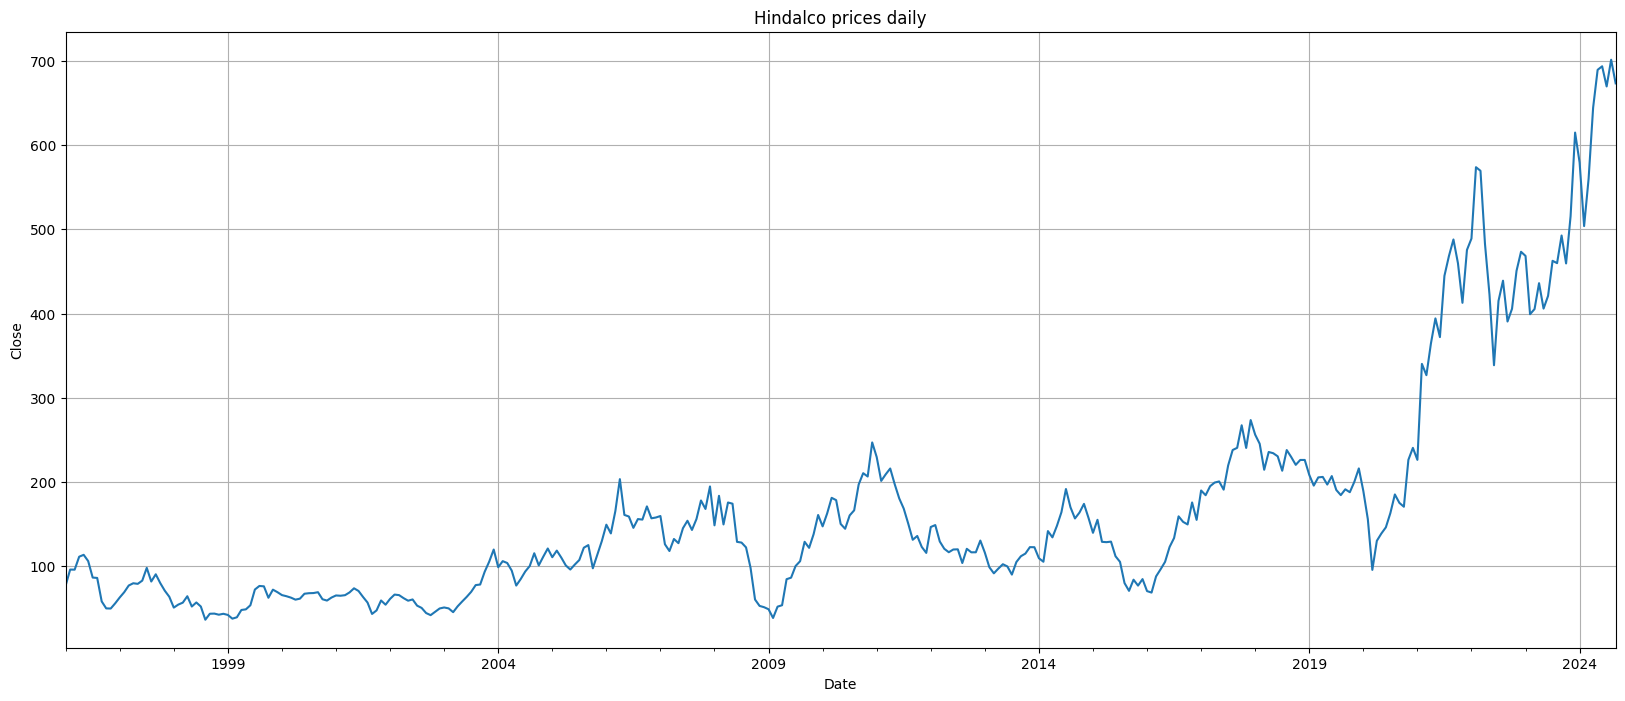

,Close
Date,
1996-01-01,77.114319
1996-02-01,96.056702
1996-03-01,95.967323
1996-04-01,111.339119
1996-05-01,113.569138


In [4]:

#Plotting the Time Series - Line graph for the chart


data['Close'].plot(figsize=(20,8))
plt.title("Hindalco prices daily")
plt.xlabel("Date")        # X-axis should represent dates
plt.ylabel("Close")       # Y-axis should represent prices
plt.grid()
plt.show()
data.head()

In [5]:
round(data.describe(),3)

,Close
count,345.000
mean,168.050
std,136.667
min,36.527
25%,77.080
50%,126.112
75%,194.720
max,701.350


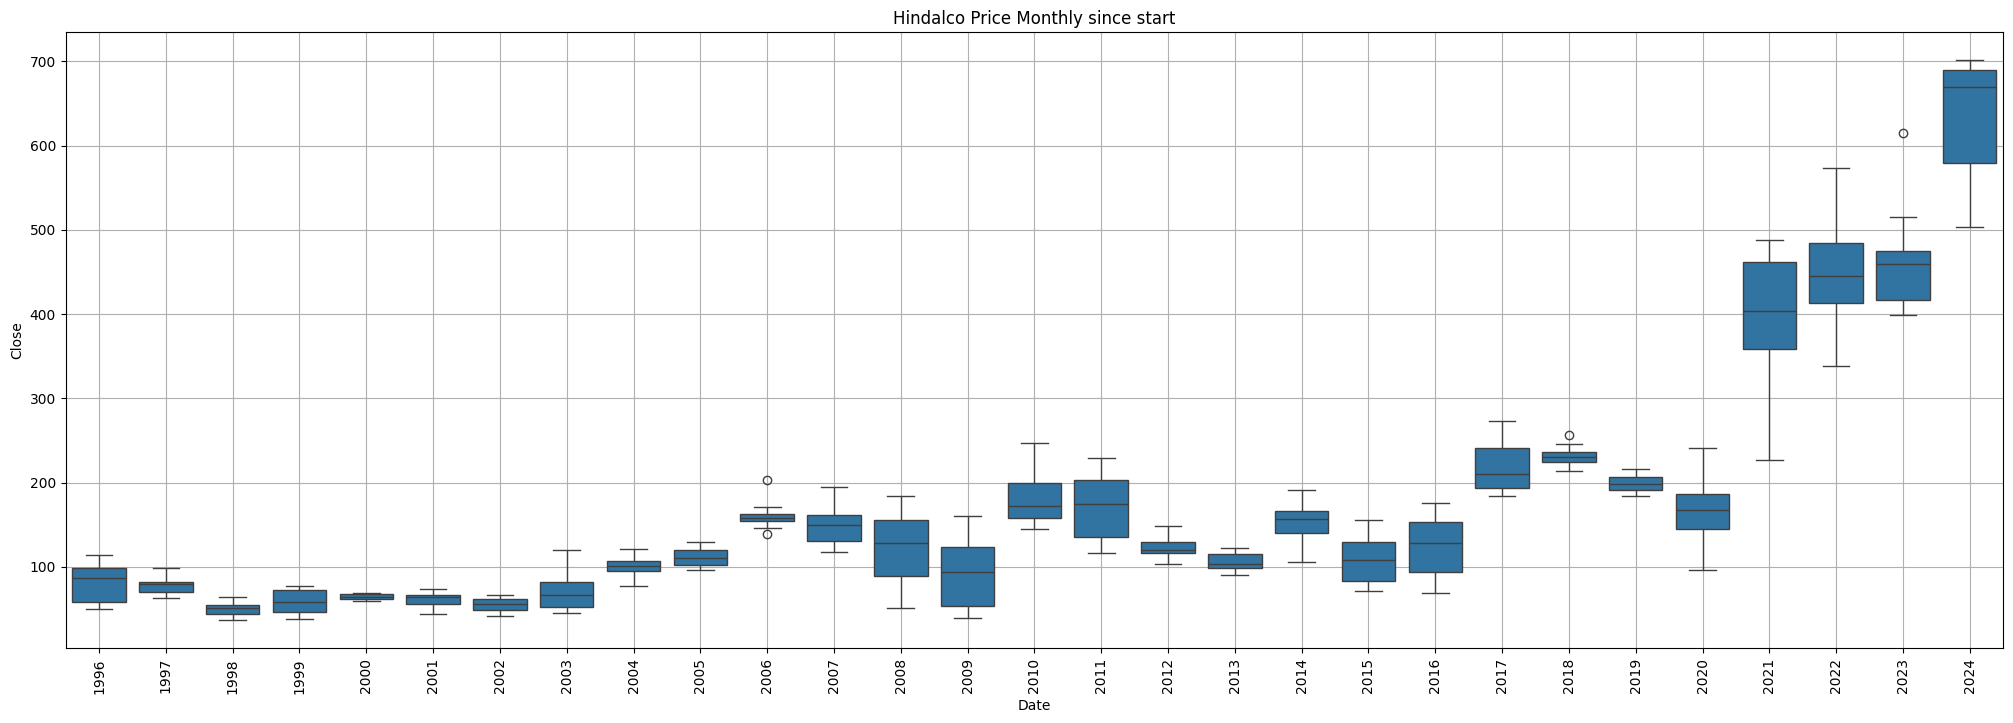

In [6]:
# Visual Analysis with Box Plots

_, ax = plt.subplots(figsize= (25,8))
sns.boxplot(x=data.index.year, y = data.values[:,0], ax=ax)
plt.title('Hindalco Price Monthly since start')
plt.xlabel('Date')
plt.ylabel('Close')
plt.xticks(rotation = 90)
plt.grid()


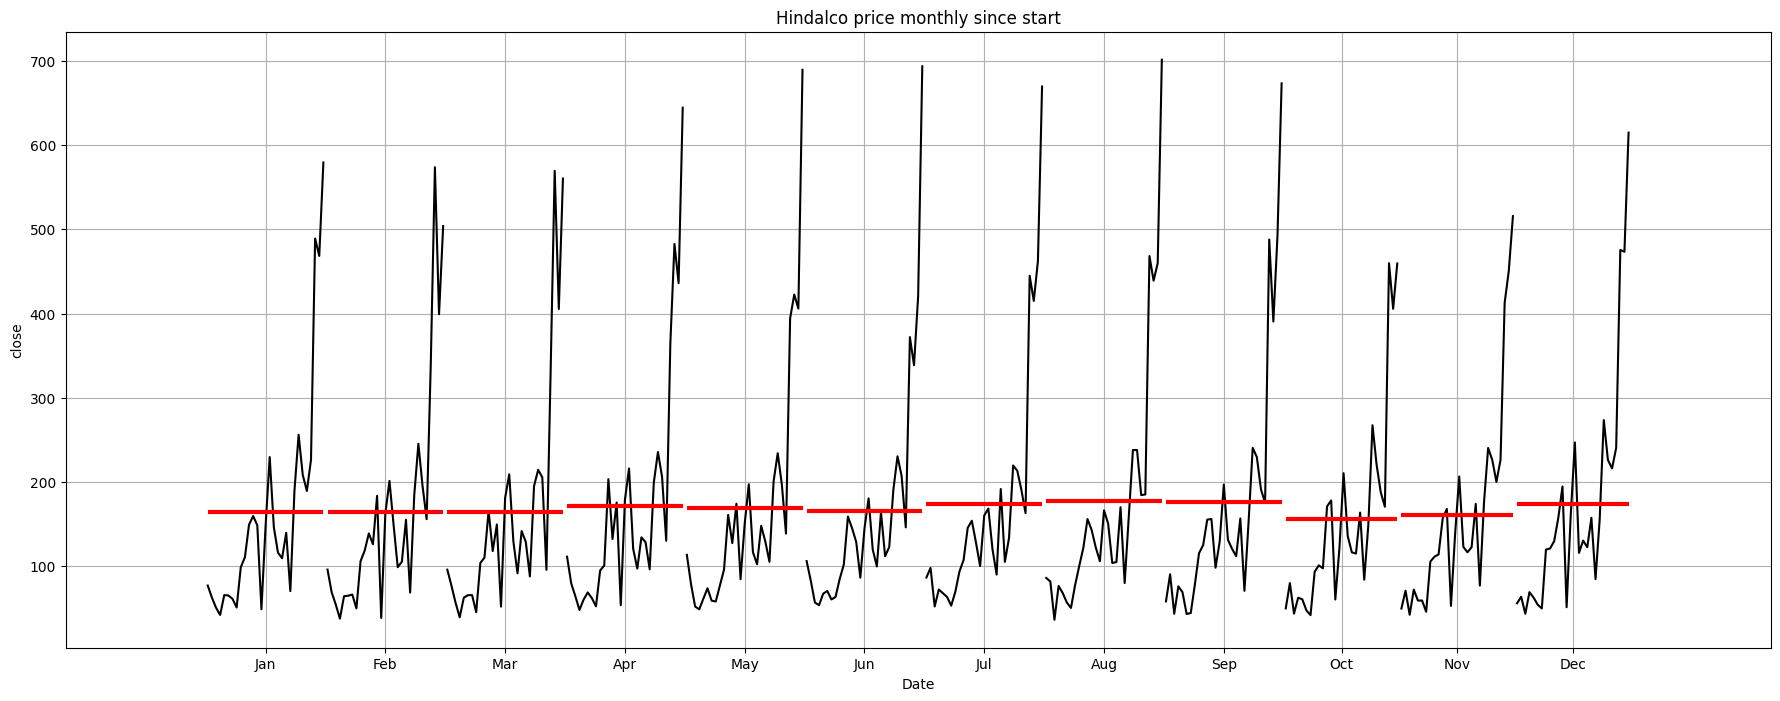

In [7]:
from statsmodels.graphics.tsaplots import month_plot

fig, ax = plt.subplots(figsize = (22,8))
month_plot(data, ylabel="Hindalco Price", ax=ax)
plt.title("Hindalco price monthly since start")
plt.xlabel("Date")
plt.ylabel("close")
plt.grid()

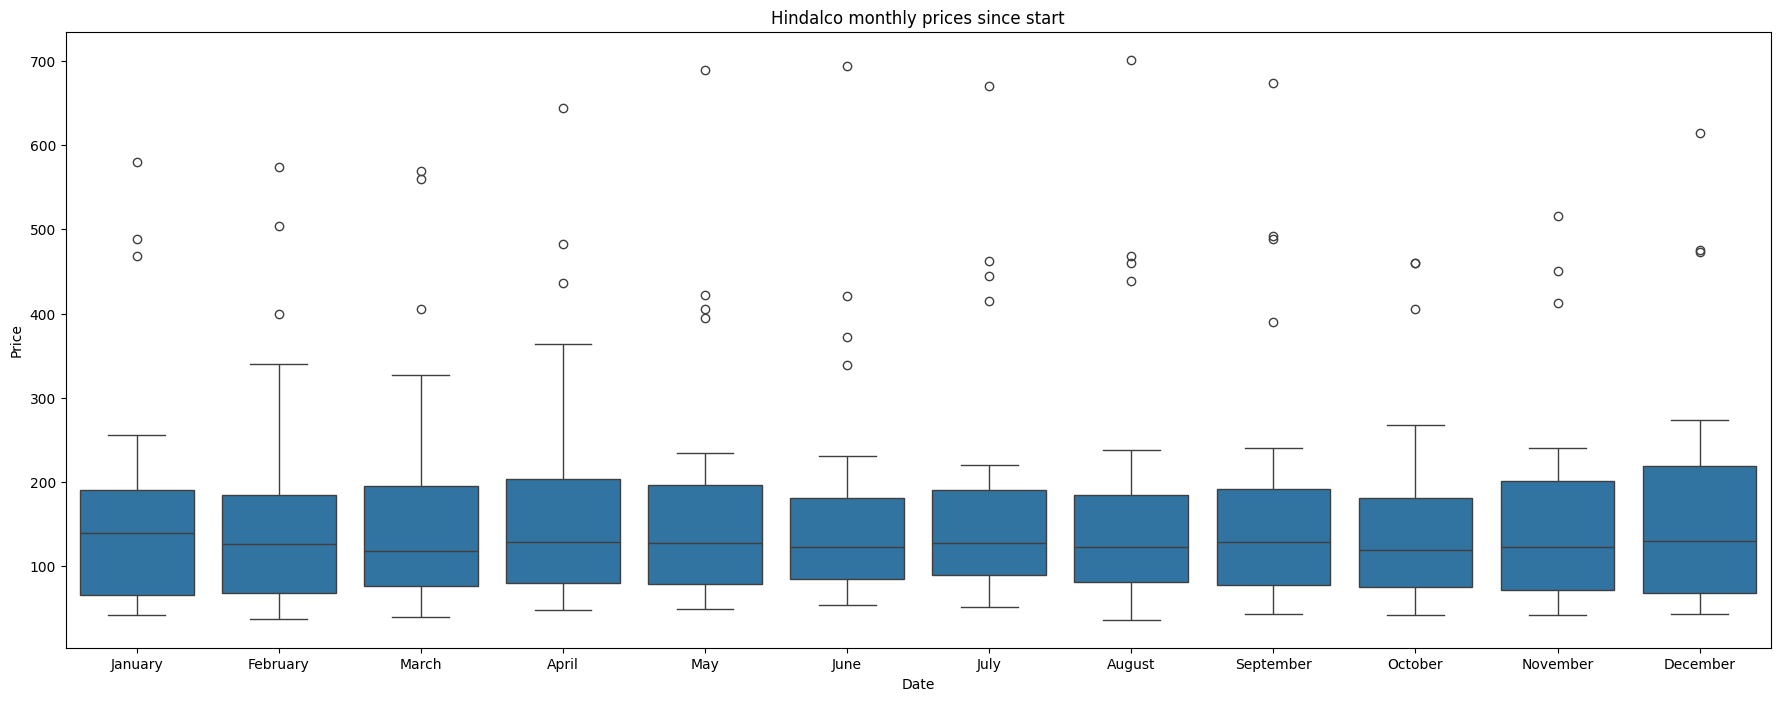

In [8]:
_, ax = plt.subplots(figsize=(22,8))
sns.boxplot(x =  data.index.month_name(), y = data.values[:,0], ax =ax)
plt.title("Hindalco monthly prices since start")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

#### Visualisation of price trend in various time periods

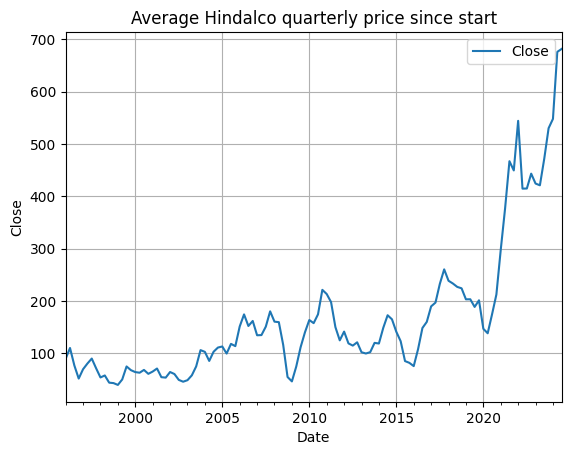

In [9]:
#Quarterly Analysis


data_quarterly_sum = data.resample('Q').mean()
data_quarterly_sum.plot()
plt.title("Average Hindalco quarterly price since start")
plt.xlabel('Date')
plt.ylabel('Close')
plt.grid()

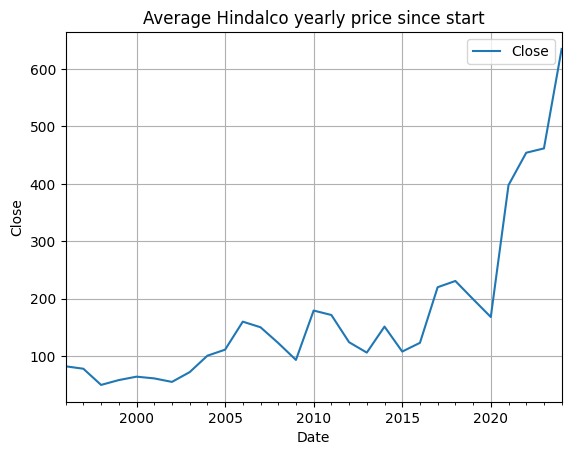

In [10]:
#Annual Analysis

data_yearly_sum = data.resample('A').mean()
data_yearly_sum.plot()
plt.title("Average Hindalco yearly price since start")
plt.xlabel('Date')
plt.ylabel('Close')
plt.grid()


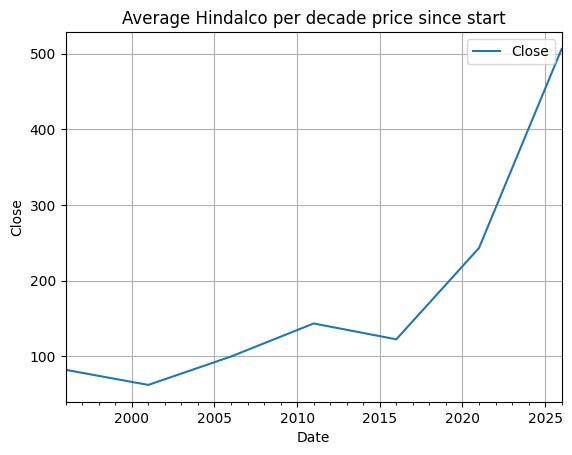

In [11]:
# 5 Year Analysis


data_decade_sum = data.resample('5Y').mean()
data_decade_sum.plot()
plt.title("Average Hindalco per decade price since start")
plt.xlabel('Date')
plt.ylabel('Close')
plt.grid()

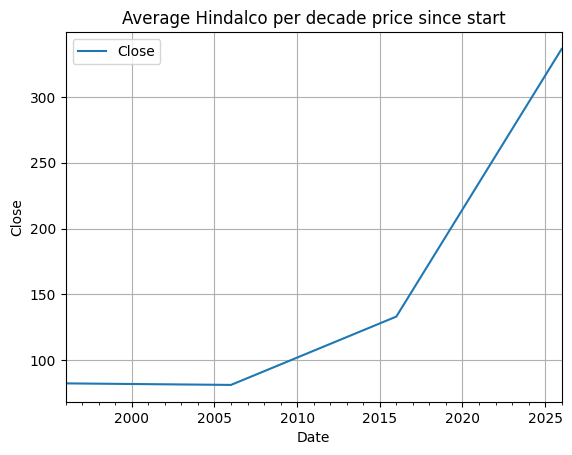

In [12]:
# Decade Analysis

data_decade_sum = data.resample('10Y').mean()
data_decade_sum.plot()
plt.title("Average Hindalco per decade price since start")
plt.xlabel('Date')
plt.ylabel('Close')
plt.grid()

#### Coefficient of Variation

-The coefficient of variation (CV) is a statistical measure of the dispersion of data points in a data series around the mean. The coefficient of variation represents the ratio of the standard deviation to the mean, and it is a useful statistic for comparing the degree of variation from one data series to another, even if the means are drastically different from one another.

- It represents the ratio of the standard deviation to the mean.
- The CV is useful for comparing the degree of variation from one data series to another, even if the means are drastically different from one another.
- In finance, the coefficient of variation allows investors to determine how much volatility, or risk, is assumed in comparison to the amount of return expected from investments.
- The lower the ratio of the standard deviation to mean return, the better the risk-return tradeoff.

In [13]:
data_1 = data.groupby(data.index.year).mean().rename(columns = {'Close': 'Mean'})
data_1 = data_1.merge(data.groupby(data.index.year).std().rename(columns={'Close': 'Std'}), left_index = True, right_index = True)
data_1['Cov_pct'] = ((data_1['Std']/data_1['Mean'])*100).round(2)
data_1.head()

,Mean,Std,Cov_pct
Date,,,
1996,82.248183,23.728446,28.85
1997,78.031793,10.279141,13.17
1998,49.839883,7.933368,15.92
1999,58.275858,14.878573,25.53
2000,64.214058,3.431674,5.34


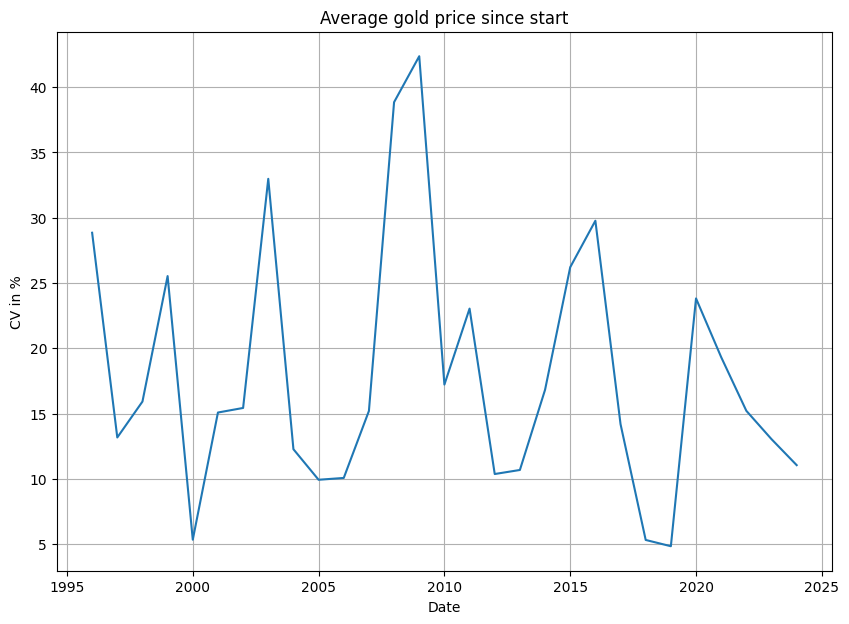

In [14]:
fig, ax = plt.subplots(figsize = (10,7))
data_1['Cov_pct'].plot()
plt.title("Average gold price since start")
plt.xlabel("Date")
plt.ylabel("CV in %")
plt.grid()